In [1]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl (8.4 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl (37.4 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ -

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [5]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (541909, 8)

Column names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5268


In [7]:
# Removing duplicate transactions
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

Shape after removing duplicates: (536641, 8)
Duplicates remaining: 0


In [8]:
# Keeping only transactions with a known CustomerID
rfm_data = df.dropna(subset=['CustomerID']).copy()

print("Shape after removing missing CustomerIDs:", rfm_data.shape)
print("Missing CustomerIDs remaining:", rfm_data['CustomerID'].isnull().sum())

Shape after removing missing CustomerIDs: (401604, 8)
Missing CustomerIDs remaining: 0


In [9]:
# Checking for cancelled transactions
cancelled = rfm_data['InvoiceNo'].astype(str).str.startswith('C')

print("Cancelled transactions:", cancelled.sum())
print("Regular transactions:", (~cancelled).sum())

Cancelled transactions: 8872
Regular transactions: 392732


In [10]:
# Removing cancelled transactions
rfm_data = rfm_data[~rfm_data['InvoiceNo'].astype(str).str.startswith('C')].copy()

print("Shape after removing cancelled transactions:", rfm_data.shape)
print("Cancelled transactions remaining:",
      rfm_data['InvoiceNo'].astype(str).str.startswith('C').sum())

Shape after removing cancelled transactions: (392732, 8)
Cancelled transactions remaining: 0


In [11]:
# Checking for invalid Quantity and UnitPrice values

print("Quantity <= 0:", (rfm_data['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (rfm_data['UnitPrice'] <= 0).sum())

Quantity <= 0: 0
UnitPrice <= 0: 40


In [12]:
# Removing transactions with invalid UnitPrice values
rfm_data = rfm_data[rfm_data['UnitPrice'] > 0].copy()

print("Shape after removing invalid prices:", rfm_data.shape)
print("Invalid UnitPrice values remaining:",
      (rfm_data['UnitPrice'] <= 0).sum())

Shape after removing invalid prices: (392692, 8)
Invalid UnitPrice values remaining: 0


In [13]:
# Calculating the total value of each transaction
rfm_data['TotalPrice'] = rfm_data['Quantity'] * rfm_data['UnitPrice']

print(rfm_data[['Quantity', 'UnitPrice', 'TotalPrice']].head())

   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [14]:
print("Earliest transaction date:", rfm_data['InvoiceDate'].min())
print("Latest transaction date:", rfm_data['InvoiceDate'].max())

Earliest transaction date: 2010-12-01 08:26:00
Latest transaction date: 2011-12-09 12:50:00


In [16]:
# Setting the reference date to one day after the last transaction
reference_date = rfm_data['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculating RFM metrics for each customer
rfm = rfm_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Rename the columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print("RFM table shape:", rfm.shape)
print(rfm.head())

RFM table shape: (4338, 3)
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [17]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


### RFM Descriptive Statistics Observation

The RFM analysis covers 4,338 customers. The average customer has a Recency of approximately 92.54 days, a Frequency of 4.27 purchases, and a Monetary value of approximately 2,048.69.

The large difference between the median and maximum values, particularly for Frequency and Monetary, indicates that a small number of customers have substantially higher purchasing activity and spending than the typical customer. This supports the use of feature standardisation before applying K-Means clustering.

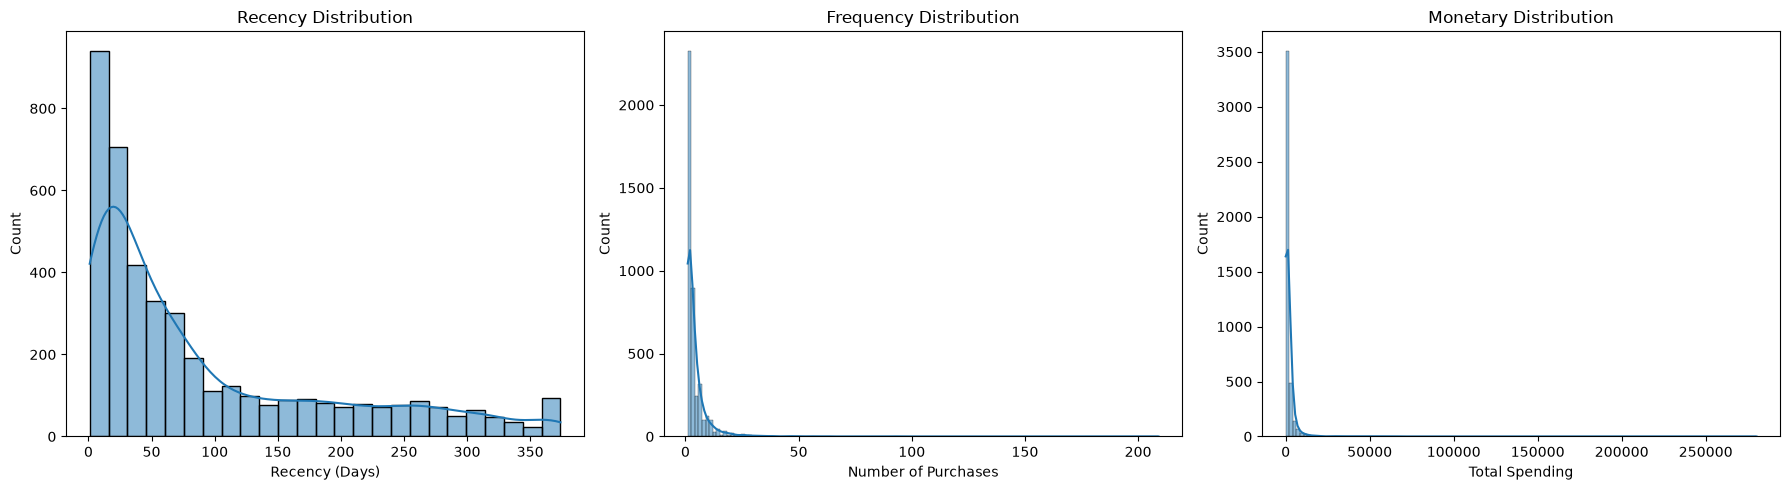

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Recency (Days)')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Purchases')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spending')

plt.tight_layout()
plt.show()

## Feature Selection for Customer Segmentation

Three key behavioural features were selected for customer segmentation using RFM analysis:

- **Recency:** Number of days since the customer's most recent purchase. Lower values indicate more recent purchasing activity.
- **Frequency:** Number of unique purchases made by the customer. Higher values indicate more frequent purchasing.
- **Monetary:** Total amount spent by the customer. Higher values indicate greater customer value.

These three features were selected because they provide complementary information about customer engagement and purchasing behaviour. Together, they allow customers to be grouped according to how recently, how often, and how much they purchase.

In [19]:
# Selecting RFM features for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardising the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Converting back to a DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

print(rfm_scaled.head())

             Recency  Frequency  Monetary
CustomerID                               
12346.0     2.334574  -0.425097  8.363010
12347.0    -0.905340   0.354417  0.251699
12348.0    -0.175360  -0.035340 -0.027988
12349.0    -0.735345  -0.425097 -0.032406
12350.0     2.174578  -0.425097 -0.190812


In [20]:
print(rfm_scaled.describe())

            Recency     Frequency      Monetary
count  4.338000e+03  4.338000e+03  4.338000e+03
mean   2.702618e-17  1.801745e-17  2.293130e-17
std    1.000115e+00  1.000115e+00  1.000115e+00
min   -9.153401e-01 -4.250965e-01 -2.276151e-01
25%   -7.453445e-01 -4.250965e-01 -1.939190e-01
50%   -4.153533e-01 -2.951776e-01 -1.536162e-01
75%    4.946227e-01  9.457903e-02 -4.319704e-02
max    2.814561e+00  2.659803e+01  3.096074e+01


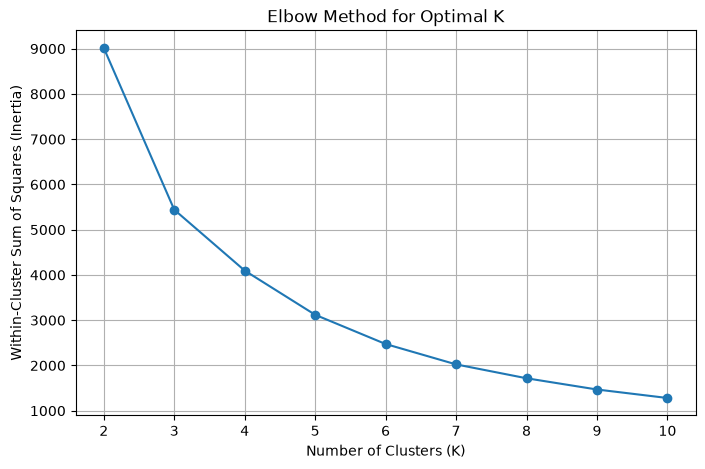

In [21]:
# Elbow Method
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [ ]:
# Applying K-Means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully!")
print("\nCluster counts:")
print(rfm['Cluster'].value_counts().sort_index())

K-Means clustering completed successfully!

Cluster counts:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [23]:
# Calculating the average RFM values for each cluster
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1353.625312
1        248.075914   1.552015     478.848773
2          7.384615  82.538462  127187.959231
3         15.500000  22.333333   12690.500392


In [24]:
# Rounding the values for easier interpretation
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


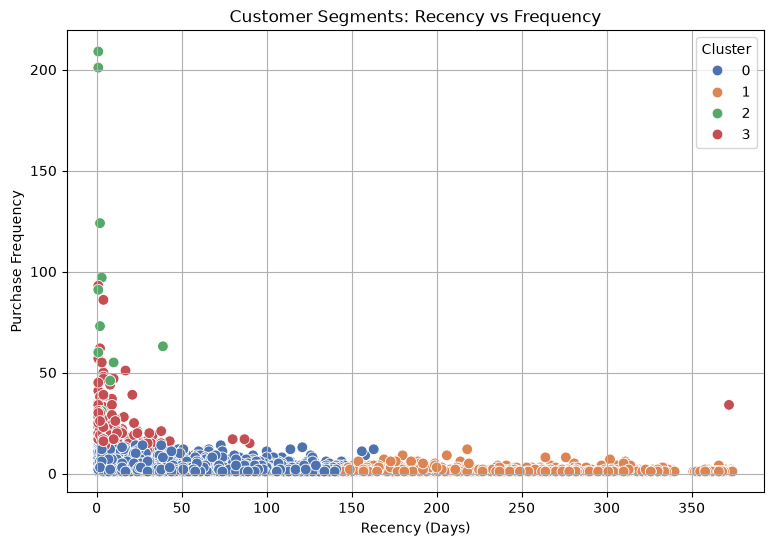

In [25]:
# Cluster visualisation: Recency vs Frequency
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='deep',
    s=60
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Purchase Frequency')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

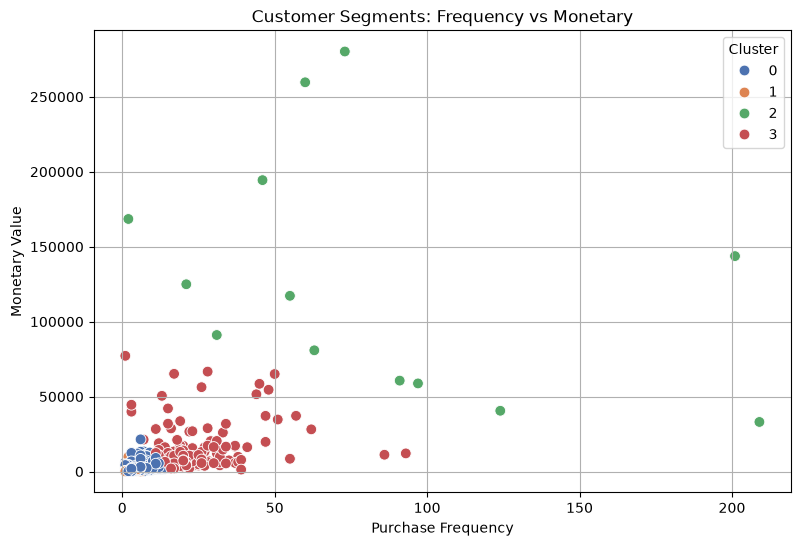

In [26]:
# Cluster visualisation: Frequency vs Monetary
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='deep',
    s=60
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

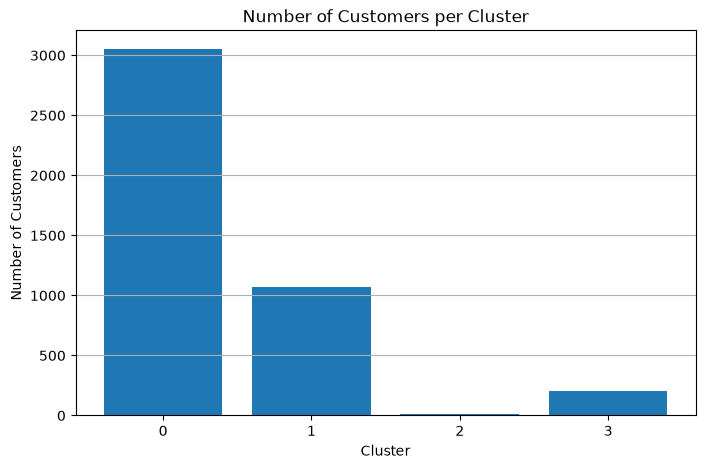

In [27]:
# Number of customers in each cluster
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.grid(axis='y')

plt.show()

## Cluster Insights and Marketing Actions

### Cluster 0: Recent/Moderate-Value Customers
These customers have relatively recent purchases, moderate purchase frequency, and moderate spending. They represent the largest customer segment.

**Marketing Action:** Encourage repeat purchases through personalised product recommendations, loyalty rewards, and targeted promotional offers.

### Cluster 1: Infrequent/Less-Recent Customers
These customers have the highest recency values, meaning they have not purchased recently. Their purchase frequency and monetary value are also relatively low.

**Marketing Action:** Use re-engagement campaigns, personalised discounts, and reminder emails to encourage these customers to return.

### Cluster 2: Very Frequent/Exceptionally High-Value Customers
This small segment has very recent purchases, extremely high purchase frequency, and exceptionally high monetary value.

**Marketing Action:** Focus on customer retention through VIP treatment, exclusive offers, personalised communication, and loyalty benefits.

### Cluster 3: Recent/Frequent/High-Value Customers
These customers purchase relatively recently and have substantially higher purchase frequency and monetary value than Clusters 0 and 1.

**Marketing Action:** Strengthen loyalty with premium offers, cross-selling, personalised recommendations, and incentives that encourage continued purchasing.